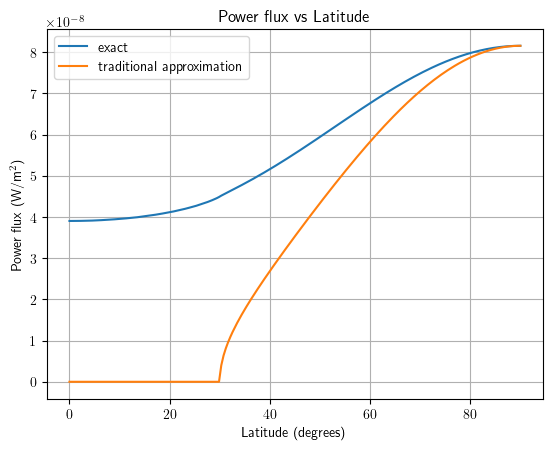

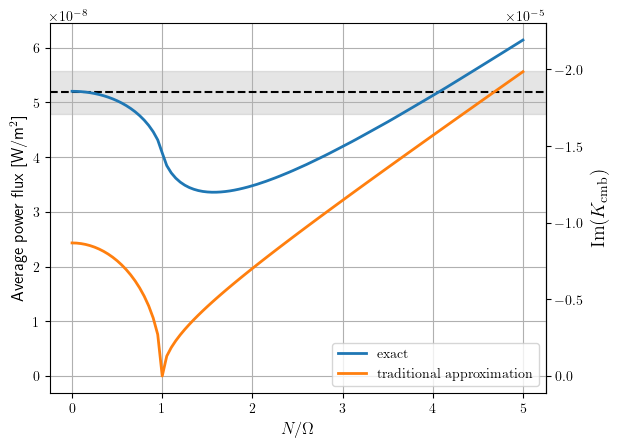

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.special import gamma
from concurrent.futures import ThreadPoolExecutor

plt.rc('text', usetex=True)
# plt.rcParams['text.usetex'] = True

# ----------------------------
# Parameters / constants
# ----------------------------
rho = 11e3
Omega = 2*np.pi/86400
U0 = 8.7e-5
R = 3486e3

k0 = 2*np.pi/1e6
H = 0.7
hrms = 6e3

# For right-axis mapping to Im(K_cmb)
ImKcmbtarget = -1.85e-5
As = 5.8531e34
Af = 9.0583e36
A  = 8.0115e37
Am = A - (As+Af)
wf = 2.4e-11
sf = - (1+Af/Am) * Af * wf**2 * Omega  # scaling: Total power (W) = sf * Im(K_cmb)
# sf = - (A/Am) * Af * wf**2 * Omega  # scaling: Total power (W) = sf * Im(K_cmb)

def scale_factor(rho, hrms, k0, H, U0, Omega):
    # return (rho/(8*np.pi**3)) * (hrms**2 * k0*H/(2*H - 1)) * (U0**2 * Omega)
    return (rho/(32*np.pi**2.5)) * (hrms**2 * k0) * (U0**2 * Omega) * gamma(H-0.5)/gamma(H)

S_factor = scale_factor(rho, hrms, k0, H, U0, Omega)

# ----------------------------
# Gauss–Legendre nodes/weights
# ----------------------------
def gl_nodes_weights(a, b, n):
    x, w = leggauss(n)
    xm = 0.5*(b - a)*x + 0.5*(b + a)
    wm = 0.5*(b - a)*w
    return xm, wm

N_ALPHA = 256
alpha, w_alpha = gl_nodes_weights(0.0, 2*np.pi, N_ALPHA)
sin_a = np.sin(alpha)
cos_a = np.cos(alpha)
sin2_a = sin_a*sin_a
cos2_a = cos_a*cos_a

N_LAT = 256
lat_nodes, w_lat = gl_nodes_weights(-np.pi/2, np.pi/2, N_LAT)
sin_lat = np.sin(lat_nodes)
cos_lat = np.cos(lat_nodes)

# ----------------------------
# Exact Pflux: integrate over alpha with fixed-grid GL
# ----------------------------
def Pflux_exact_gl(NoverOmega, lat):
    s = np.sin(lat)
    c = np.cos(lat)
    expr = (NoverOmega**2 - 1.0) * (1.0 - 4.0*s*s) + 4.0*c*c*sin2_a
    mask = expr > 0.0
    if not np.any(mask):
        return 0.0
    val = np.zeros_like(expr)
    val[mask] = np.sqrt(expr[mask]) * (s*s*cos2_a[mask] + sin2_a[mask])
    return np.dot(w_alpha, val)

def Pflux_exact_gl_latgrid(NoverOmega, lat_array):
    s = np.sin(lat_array)
    c = np.cos(lat_array)
    s2 = s*s
    c2 = c*c

    expr = (NoverOmega**2 - 1.0) * (1.0 - 4.0*s2)[:, None] + 4.0*c2[:, None] * sin2_a[None, :]
    mask = expr > 0.0

    factor = s2[:, None] * cos2_a[None, :] + sin2_a[None, :]

    val = np.zeros_like(expr)
    val[mask] = np.sqrt(expr[mask]) * factor[mask]

    return val @ w_alpha

# ----------------------------
# Traditional approximation: analytic alpha integral (vectorized)
# ----------------------------
def Pflux_trad_analytic_latgrid(NoverOmega, lat_array):
    s = np.sin(lat_array)
    s2 = s*s
    expr = (NoverOmega**2 - 1.0) * (1.0 - 4.0*s2)
    out = np.zeros_like(lat_array, dtype=float)
    mask = expr > 0.0
    out[mask] = np.sqrt(expr[mask]) * (np.pi * (1.0 + s2[mask]))
    return out

# ----------------------------
# Surface totals by GL in latitude
# ----------------------------
def total_power_exact_gl(NoverOmega):
    p = Pflux_exact_gl_latgrid(NoverOmega, lat_nodes)
    integrand = p * (R**2) * 2*np.pi * cos_lat
    return np.dot(w_lat, integrand)

def total_power_trad_gl(NoverOmega):
    p = Pflux_trad_analytic_latgrid(NoverOmega, lat_nodes)
    integrand = p * (R**2) * 2*np.pi * cos_lat
    return np.dot(w_lat, integrand)

# ----------------------------
# Demo: latitude plot at N/Omega = 0.5
# ----------------------------
latitudes = np.linspace(0.0, np.pi/2, 200)
N_demo = 0.5

pf_exact = np.array([Pflux_exact_gl(N_demo, lat) for lat in latitudes])
pf_trad  = Pflux_trad_analytic_latgrid(N_demo, latitudes)

fig, ax = plt.subplots()
ax.plot(np.degrees(latitudes), S_factor * pf_exact, label="exact")
ax.plot(np.degrees(latitudes), S_factor * pf_trad,  label="traditional approximation")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel(r"Power flux (W/m$^2$)")
ax.set_title("Power flux vs Latitude")
ax.grid(True)
ax.legend()
plt.show()

# ----------------------------
# N sweep (notebook-safe parallelism: threads)
# ----------------------------
N_values = np.linspace(0.0, 5.0, 101)

def compute_one(N):
    return total_power_exact_gl(N), total_power_trad_gl(N)

with ThreadPoolExecutor() as ex:
    out = list(ex.map(compute_one, N_values))

results_exact = np.array([o[0] for o in out])
results_trad  = np.array([o[1] for o in out])

# ----------------------------
# Total power plot with secondary y-axis, dashed line, and shaded band
# ----------------------------
fig, ax = plt.subplots()

#ax.plot(N_values, S_factor * results_exact, marker='o', linestyle='-', label="exact")
#ax.plot(N_values, S_factor * results_trad,  marker='o', linestyle='-', label="traditional approximation")

# Target line and shaded band in Im(K_cmb), mapped into left-axis units using sf
ax.axhline(y=sf * ImKcmbtarget/(4*np.pi*R**2), color='k', linestyle='--')

ax.set_xlim(N_values[0] - 0.25, N_values[-1] + 0.25)
x_fill = np.linspace(N_values[0] - 0.25, N_values[-1] + 0.25, 200)
ax.fill_between(
    x_fill,
    sf * (-1.99e-5)/(4*np.pi*R**2),
    sf * (-1.71e-5)/(4*np.pi*R**2),
    color='gray',
    alpha=0.2
)

ax.plot(N_values, S_factor * results_exact/(4*np.pi*R**2), lw=2, label=r"$\mathrm{exact}$")
ax.plot(N_values, S_factor * results_trad/(4*np.pi*R**2),  lw=2, label=r"$\mathrm{traditional~approximation}$")

ax.set_xlabel(r"$N/\Omega$", fontsize=12)
ax.set_ylabel(r"Average power flux [W/m$^2$]", fontsize=12)
ax.grid(True)
ax.legend()

# Right axis: Im(K_cmb)
secax = ax.secondary_yaxis(
    'right',
    functions=(lambda y: y / sf * (4*np.pi*R**2),   # left -> right
               lambda k: k * sf /(4*np.pi*R**2))   # right -> left
)
secax.set_ylabel(r'$\mathrm{Im}(K_\mathrm{cmb})$', fontsize=14)

plt.savefig("Average_power_flux.pdf", bbox_inches="tight")
plt.show()
